# Handwritten Digit Recognition with a Neural Network Built from Scratch

This tutorial builds a two-layer neural network that recognizes handwritten
digits, using only **NumPy**.

**Dataset**: The classic MNIST of $28 \times 28$ grayscale images
of the digits $0$ through $9$, in the CSV form distributed by the Kaggle
[Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer)
competition.

## The network

A fully connected network with one hidden layer:

$$
\underbrace{x}_{784\times 1}
\;\longrightarrow\;
\boxed{\text{linear } W^{[1]}, b^{[1]}}
\;\longrightarrow\;
\boxed{\text{ReLU}}
\;\longrightarrow\;
\boxed{\text{linear } W^{[2]}, b^{[2]}}
\;\longrightarrow\;
\boxed{\text{softmax}}
\;\longrightarrow\;
\underbrace{\hat{y}}_{10\times 1}
$$

Trained by batch gradient descent on the cross-entropy loss.

## Roadmap

| Section | Topic |
|---|---|
| 1–3 | Setup, the data, and its matrix representation |
| 4 | Architecture and parameter initialization |
| 5 | Forward propagation: affine maps, ReLU, softmax |
| 6 | One-hot encoding and the cross-entropy loss |
| 7 | Backpropagation, derived step by step |
| 8–9 | The update rule and the training loop |
| 10–11 | Evaluation and inspection of the learned weights |
| 12 | Appendix: verifying the gradients numerically |


## Notation

| Symbol | Meaning |
|---|---|
| $m$ | number of examples in the batch |
| $n_x = 784$ | number of input features (pixels per image) |
| $n_h = 10$ | number of hidden units |
| $n_y = 10$ | number of output classes |
| $X \in \mathbb{R}^{n_x \times m}$ | input matrix; **one column per example** |
| $x^{(i)}$ | the $i$-th example, i.e., the $i$-th column of $X$ |
| $W^{[\ell]}, b^{[\ell]}$ | weights and biases of layer $\ell$ |
| $Z^{[\ell]}$ | pre-activations of layer $\ell$ |
| $A^{[\ell]}$ | activations (post-nonlinearity) of layer $\ell$ |
| $Y \in \mathbb{R}^{n_y \times m}$ | one-hot encoded labels |
| $\odot$ | elementwise (Hadamard) product |

In this tutorial, we use the convention: **examples are columns, not rows.** 
For instance, a batch of $m$ images is a $784 \times m$ matrix. 

---
## 1. Setup

Three libraries are needed: `NumPy` for the arithmetic, `pandas` to read the CSV,
and `Matplotlib` to look at the images and the training curves.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Fixed seed to make the results reproducible.
RNG_SEED = 0

---
## 2. The data

The file `train.csv` contains 42,000 labelled images. Each row is one image:

* column `label` — the digit actually drawn, an integer in $\{0, 1, \dots, 9\}$;
* columns `pixel0` … `pixel783` — the $28 \times 28 = 784$ pixel intensities,
  each an integer in $[0, 255]$, listed in row-major order.

So the raw table has $42{,}000$ rows and $785$ columns.

**Getting the file.** Nothing to download. It ships with this repository at
`data/train.csv.gz`, and `pandas` reads the compressed file directly.

The cell below also checks for an uncompressed `data/train.csv`, the notebook's
own folder, and your Google Drive, mounting Drive only if it is running inside
Colab. Any of those works if you already have a copy.

In [2]:
from pathlib import Path

# Where train.csv might live, checked in order.
CANDIDATE_PATHS = [
    Path("data/train.csv.gz"),                                  # ships with this repository
    Path("data/train.csv"),                                     # uncompressed, if you have it
    Path("train.csv.gz"),                                       # same folder
    Path("train.csv"),                                          # same folder
    Path("/content/drive/MyDrive/digit-recognizer/train.csv"),  # Drive, inside Colab
]

# Google Drive for Desktop syncs Drive into a local folder whose exact name
# depends on the account, so we glob for it rather than hard-coding one.
DRIVE_PATTERNS = [
    "My Drive*/digit-recognizer/train.csv",
    "Google Drive*/digit-recognizer/train.csv",
    "Library/CloudStorage/GoogleDrive*/My Drive/digit-recognizer/train.csv",
]


def locate_training_csv():
    """Find train.csv locally, in a synced Google Drive, or by mounting Drive in Colab."""
    for path in CANDIDATE_PATHS:
        if path.exists():
            return path

    # Google Drive for Desktop, already synced onto this machine.
    for pattern in DRIVE_PATTERNS:
        for path in sorted(Path.home().glob(pattern)):
            return path

    # Running inside Colab: mount Drive, then look again.
    try:
        from google.colab import drive
    except ImportError:
        pass
    else:
        drive.mount("/content/drive")
        for path in CANDIDATE_PATHS:
            if path.exists():
                return path

    raise FileNotFoundError(
        "Could not find the training data. It ships with this repository at "
        "data/train.csv.gz, so if it is missing, re-clone from "
        "https://github.com/RibeiroResearch/neural-nets-tutorials or place a "
        "copy at one of: " + ", ".join(str(p) for p in CANDIDATE_PATHS)
    )


csv_path = locate_training_csv()
data = pd.read_csv(csv_path)
print(f"Loaded {csv_path}  ->  {data.shape[0]} rows x {data.shape[1]} columns")

Loaded data/train.csv  ->  42000 rows x 785 columns


In [3]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---
## 3. From a table of pixels to matrices

### 3.1 Shuffling and splitting

The rows of the CSV are not guaranteed to be in random order, so we shuffle
before splitting. We then hold out the last 20% of the examples as a
**validation set**. 

$$
\underbrace{42{,}000 \text{ examples}}_{\text{all data}}
\;=\;
\underbrace{33{,}600}_{\text{training}} \;+\; \underbrace{8{,}400}_{\text{validation}}.
$$

### 3.2 The design matrix

After splitting, each subset is transposed so that **each column is one
example**:

$$
X \;=\;
\begin{bmatrix}
\big| & \big| & & \big| \\
x^{(1)} & x^{(2)} & \cdots & x^{(m)} \\
\big| & \big| & & \big|
\end{bmatrix}
\;\in\; \mathbb{R}^{784 \times m},
\qquad
x^{(i)} \in \mathbb{R}^{784}.
$$

The labels stay as a plain vector $y \in \{0,\dots,9\}^{m}$ for now. Section 6
turns them into one-hot columns.

### 3.3 Scaling

Raw intensities $\in$ $[0, 255]$. We rescale them to $[0, 1]$:

$$
x \;\leftarrow\; \frac{x}{255}.
$$

Dividing by 255 keeps every quantity in the
network at a manageable scale. The pre-activation of a hidden unit is a sum
of 784 terms $w_j x_j$; with $x_j$ as large as 255 those sums reach into the
thousands, the softmax saturates, and the gradients that come back are either
enormous or numerically zero.

In [4]:
rng = np.random.default_rng(RNG_SEED)

data_array = np.array(data)          # (42000, 785): label in column 0
m_total, n_columns = data_array.shape
rng.shuffle(data_array)              # shuffles rows in place

n_train = int(0.8 * m_total)
train_data = data_array[:n_train, :]
val_data = data_array[n_train:, :]

# Transpose so that columns are examples, and scale pixels to [0, 1].
X_train = train_data[:, 1:].T / 255.0
Y_train = train_data[:, 0]

X_val = val_data[:, 1:].T / 255.0
Y_val = val_data[:, 0]

print(f"total examples: {m_total},  columns per row: {n_columns}")

total examples: 42000,  columns per row: 785


In [5]:
print(f"X_train: {X_train.shape}   Y_train: {Y_train.shape}")
print(f"X_val:   {X_val.shape}    Y_val:   {Y_val.shape}")
print(f"pixel range after scaling: [{X_train.min():.1f}, {X_train.max():.1f}]")

X_train: (784, 33600)   Y_train: (33600,)
X_val:   (784, 8400)    Y_val:   (8400,)
pixel range after scaling: [0.0, 1.0]


### Visualizing the input
Reshape each column of
`X_train` to a $28 \times 28$ matrix.

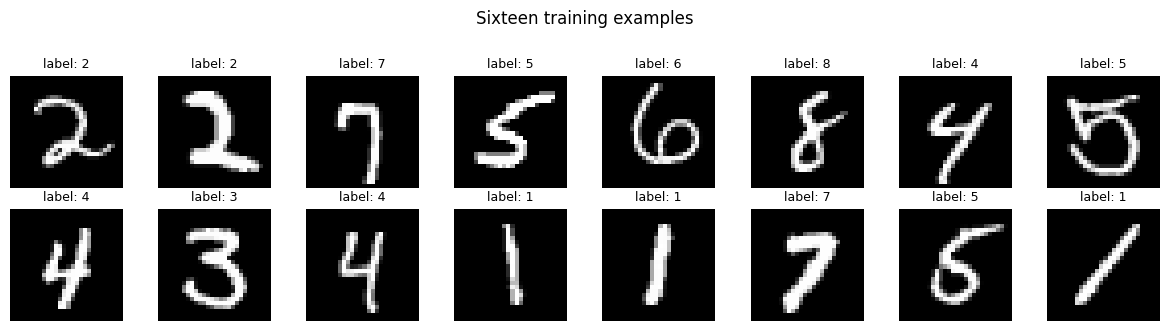

In [6]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for k, ax in enumerate(axes.flat):
    ax.imshow(X_train[:, k].reshape(28, 28), cmap="gray")
    ax.set_title(f"label: {Y_train[k]}", fontsize=9)
    ax.axis("off")
fig.suptitle("Sixteen training examples", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. The architecture

The network has one hidden layer of 10 ReLU units and an output layer of 10
softmax units:

| Layer | Operation | Shape of parameters | Output shape |
|---|---|---|---|
| input | — | — | $784 \times m$ |
| hidden | $Z^{[1]} = W^{[1]}X + b^{[1]}$, then ReLU | $W^{[1]}: 10\times784$, $b^{[1]}: 10\times1$ | $10 \times m$ |
| output | $Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}$, then softmax | $W^{[2]}: 10\times10$, $b^{[2]}: 10\times1$ | $10 \times m$ |

That is $784 \cdot 10 + 10 + 10 \cdot 10 + 10 = 7{,}960$ trainable parameters.

### Initialization

We draw every parameter from $\mathcal{U}(-0.5, 0.5)$, so that the initial
weights are small, centred at zero:

$$
W^{[\ell]}_{jk}, \; b^{[\ell]}_j \;\sim\; \mathcal{U}(-0.5,\, 0.5).
$$

In [7]:
def initialize_parameters(n_x=784, n_h=10, n_y=10, seed=RNG_SEED):
    """Draw the four parameter arrays from U(-0.5, 0.5)."""
    rng = np.random.default_rng(seed)
    W1 = rng.random((n_h, n_x)) - 0.5
    b1 = rng.random((n_h, 1)) - 0.5
    W2 = rng.random((n_y, n_h)) - 0.5
    b2 = rng.random((n_y, 1)) - 0.5
    return W1, b1, W2, b2


W1, b1, W2, b2 = initialize_parameters()
for name, P in [("W1", W1), ("b1", b1), ("W2", W2), ("b2", b2)]:
    print(f"{name}: {str(P.shape):12s} {P.size:6d} parameters")
print(f"total: {W1.size + b1.size + W2.size + b2.size} parameters")

W1: (10, 784)      7840 parameters
b1: (10, 1)          10 parameters
W2: (10, 10)        100 parameters
b2: (10, 1)          10 parameters
total: 7960 parameters


> **A note on the scale of the initialization.** Uniform $(-0.5, 0.5)$ is simple
> and works here, but it is not what a modern library would do. A hidden unit
> sums 784 weighted inputs, so the variance of $z$ grows with the number of
> incoming connections. [**He initialization**](https://en.wikipedia.org/wiki/Weight_initialization) compensates by drawing
> $W^{[\ell]} \sim \mathcal{N}\!\left(0, \tfrac{2}{n_{\ell-1}}\right)$, which keeps
> the variance of the activations roughly constant from layer to layer and
> matters a great deal in deeper networks.

---
## 5. Forward propagation

Forward propagation runs a batch of images through the network
to obtain predicted class probabilities. In this network, it has the following 4 steps.

### 5.1 The affine step

$$
Z^{[1]} \;=\; W^{[1]} X + b^{[1]}
\qquad
\underbrace{(10 \times m)}_{Z^{[1]}}
= \underbrace{(10 \times 784)}_{W^{[1]}}\underbrace{(784 \times m)}_{X}
+ \underbrace{(10 \times 1)}_{b^{[1]}}
$$

**Single example**: For one
image $x^{(i)} \in \mathbb{R}^{784}$, the product $W^{[1]}x^{(i)}$ is a
$10 \times 1$ column and $b^{[1]}$ is a $10 \times 1$ column. They add
element-wise:

$$
z^{[1](i)} \;=\; W^{[1]} x^{(i)} + b^{[1]}
$$

**Stacking all $m$ examples side by side**: $X$ becomes $784 \times m$, so
$W^{[1]}X$ becomes $10 \times m$, i.e., one output column per example. But there is
still only *one* bias vector, because $W^{[1]}$ and $b^{[1]}$ are shared by
every image in the dataset. That single $10 \times 1$ column now has to be added
to each of the $m$ columns.

Numpy **broadcasting**: given a $10 \times m$ array and a
$10 \times 1$ array, NumPy adds the bias to every column. Nothing is copied in
memory. Vector $b^{[1]}$ stays $10 \times 1$, and the replication is virtual.

The repetition is needed because of *batching*. It does not happen if we feed the network
one image at a time.

One thing to carry into Section 7: because $b^{[1]}$ is used $m$ times in the
forward pass, the chain rule collects a contribution from each of those uses, so
its gradient is a **sum over examples**. Broadcasting forwards becomes summation
backwards, which is why $db^{[1]}$ sums over the columns rather than over
everything.

### 5.2 The ReLU nonlinearity

$$
A^{[1]} \;=\; \operatorname{ReLU}\!\left(Z^{[1]}\right),
\qquad
\operatorname{ReLU}(z) = \max(0, z).
$$

ReLU's derivative:

$$
\operatorname{ReLU}'(z) \;=\;
\begin{cases}
1 & z > 0 \\
0 & z < 0
\end{cases}
$$

At $z = 0$ the function is not differentiable. Here, we set the
derivative to be $0$ by convention.

### 5.3 The softmax output

The final layer must produce a probability distribution over the ten digits.
The softmax function does this by exponentiating and normalizing, applied
**independently to each column**:

$$
a^{[2]}_k \;=\; \operatorname{softmax}\!\left(z^{[2]}\right)_k
\;=\; \frac{e^{z^{[2]}_k}}{\sum_{j=0}^{9} e^{z^{[2]}_j}},
\qquad k = 0, \dots, 9 .
$$

Exponentiating makes every entry positive; dividing by the sum makes the
entries add to one. So $a^{[2]}_k \ge 0$ and $\sum_k a^{[2]}_k = 1$: we may read
$a^{[2]}_k$ as the model's estimate of $P(\text{digit} = k \mid x)$.

**Numerical stability.** Computing $e^{z_k}$ directly overflows as soon as
$z_k$ exceeds about 709 in double precision. The fix relies on the fact that
softmax is invariant to a constant shift of its input: for any $c$,

$$
\frac{e^{z_k - c}}{\sum_j e^{z_j - c}}
= \frac{e^{-c} e^{z_k}}{e^{-c}\sum_j e^{z_j}}
= \frac{e^{z_k}}{\sum_j e^{z_j}} .
$$

Choosing $c = \max_j z_j$ makes the largest exponent exactly $e^0 = 1$, avoiding overflow. 

In [8]:
def ReLU(Z):
    """Elementwise max(0, z)."""
    return np.maximum(Z, 0)


def softmax(Z):
    """Column-wise softmax, shifted by the column max for numerical stability."""
    Z_shifted = Z - np.max(Z, axis=0, keepdims=True)
    exponentials = np.exp(Z_shifted)
    return exponentials / np.sum(exponentials, axis=0, keepdims=True)

#### A quick look at the two nonlinearities


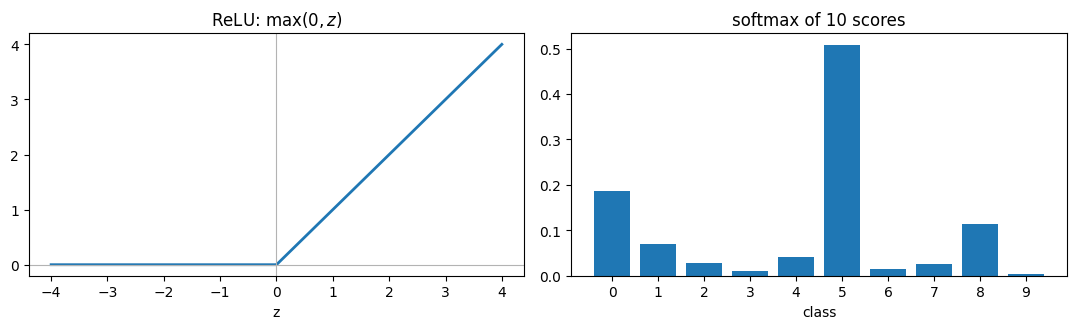

In [9]:
# A quick look at the two nonlinearities.
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 3.4))

z = np.linspace(-4, 4, 400)
ax_left.plot(z, ReLU(z), lw=2)
ax_left.axhline(0, color="0.7", lw=0.8)
ax_left.axvline(0, color="0.7", lw=0.8)
ax_left.set_title(r"ReLU: $\max(0, z)$")
ax_left.set_xlabel("z")

scores = np.array([[2.0], [1.0], [0.1], [-1.0], [0.5], [3.0], [-0.5], [0.0], [1.5], [-2.0]])
probabilities = softmax(scores)
ax_right.bar(np.arange(10), probabilities.ravel())
ax_right.set_title(f"softmax of 10 scores")
ax_right.set_xlabel("class")
ax_right.set_xticks(np.arange(10))

plt.tight_layout()
plt.show()

Putting the four equations together:

$$
\begin{aligned}
Z^{[1]} &= W^{[1]} X + b^{[1]} \\
A^{[1]} &= \operatorname{ReLU}\!\left(Z^{[1]}\right) \\
Z^{[2]} &= W^{[2]} A^{[1]} + b^{[2]} \\
A^{[2]} &= \operatorname{softmax}\!\left(Z^{[2]}\right)
\end{aligned}
$$

The function returns all four intermediate results, not just the final
$A^{[2]}$. These values are stored because backpropagation needs $Z^{[1]}$ and $A^{[1]}$
to compute its derivatives, and recomputing them later would cost a second
forward pass. Caching activations on the way forward is done internally by 
frameworks like PyTorch.

In [10]:
def forward_propagation(W1, b1, W2, b2, X):
    """Run a batch X (784 x m) through the network, caching intermediates."""
    Z1 = W1.dot(X) + b1          # (10 x m), bias broadcast across columns
    A1 = ReLU(Z1)                # (10 x m)
    Z2 = W2.dot(A1) + b2         # (10 x m)
    A2 = softmax(Z2)             # (10 x m), each column sums to 1
    return Z1, A1, Z2, A2


# Sanity check on a batch of five examples.
Z1, A1, Z2, A2 = forward_propagation(W1, b1, W2, b2, X_train[:, :5])
print("A2 shape:", A2.shape)
print("column sums (should all be 1):", np.round(A2.sum(axis=0), 6))

A2 shape: (10, 5)
column sums (should all be 1): [1. 1. 1. 1. 1.]


---
## 6. Measuring the error: cross-entropy

### 6.1 One-hot encoding

The network outputs a distribution over ten classes, but a label is a single
integer. To compare them, we express the label as a distribution that
places all its mass on the correct digit:

$$
y = 3
\quad\longmapsto\quad
\mathbf{y} = (0,0,0,1,0,0,0,0,0,0)^{\!\top}.
$$

Formally, $\mathbf{y}_k = 1$ if $k$ equals the true label and $0$ otherwise.
Stacking these columns for the whole batch gives $Y \in \{0,1\}^{10 \times m}$,
matching the shape of $A^{[2]}$.

We fix the number of columns at 10 rather than inferring it from the labels
present, so that the encoding is correct even for a batch that happens to
contain no examples of some digit.

### 6.2 The loss function

We measure the discrepancy between the predicted distribution $a^{[2]}$ and the
target $\mathbf{y}$ with the **categorical cross-entropy**, averaged over the
batch:

$$
\mathcal{L}
\;=\; -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=0}^{9}
\mathbf{y}^{(i)}_k \,\log a^{[2](i)}_k .
$$

Because $\mathbf{y}^{(i)}$ is one-hot, the inner sum's surviving
term is the one for the true class $k^{(i)}$, and the loss becomes: 

$$
\mathcal{L} \;=\; -\frac{1}{m}\sum_{i=1}^{m} \log a^{[2](i)}_{k^{(i)}},
$$

i.e., the average negative log-probability assigned to the right answer. If the
network is confident and correct, $a_{k} \to 1$ and the loss goes to $0$; if it
is confident and wrong, $a_k \to 0$ and the loss grows without bound. The 
loss will induce a mild reward if the model is right, and a high penalty if the model is 
confidently wrong. 

Minimizing this loss is equivalent to **maximum likelihood estimation**: it is
the negative log-likelihood of the observed labels under the model's predicted
distribution.

A small constant $\varepsilon = 10^{-9}$ is added inside the logarithm to avoid
$\log 0$ when a probability underflows to exactly zero.

In [11]:
def one_hot(Y, num_classes=10):
    """Turn a label vector (m,) into a one-hot matrix (num_classes x m)."""
    one_hot_Y = np.zeros((Y.size, num_classes))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T


def cross_entropy_loss(A2, Y_onehot, epsilon=1e-9):
    """Average categorical cross-entropy over the columns of the batch."""
    m = Y_onehot.shape[1]
    return -np.sum(Y_onehot * np.log(A2 + epsilon)) / m


# Demonstration on the first five labels.
print("labels:", Y_train[:5])
print("one-hot encoding (10 x 5):")
print(one_hot(Y_train[:5]).astype(int))

labels: [2 2 7 5 6]
one-hot encoding (10 x 5):
[[0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


**A network that guessed uniformly at random would score:** $-log(1/10) = log(10)$

In [12]:
# A network that guessed uniformly at random would score -log(1/10) = log(10).
_, _, _, A2_initial = forward_propagation(W1, b1, W2, b2, X_train)
print(f"loss at initialization: {cross_entropy_loss(A2_initial, one_hot(Y_train)):.4f}")
print(f"loss of a uniform guesser: {np.log(10):.4f}")

loss at initialization: 2.8402
loss of a uniform guesser: 2.3026


**A useful reference point**: a network that ignored its input and predicted
$a_k = 1/10$ for every class would incur a loss of exactly
$-\log(1/10) = \log 10 \approx 2.303$. This value should be beaten by any trained model. 

The untrained network above scores *worse* than $2.303$. Its predictions are not uniform: each $z^{[2]}_k$ is a sum of many
random terms, so some are large, the softmax sharpens them into confident
predictions, and those predictions are confidently wrong about as often as by 
chance. Cross-entropy punishes confident errors, so the loss
starts above the uniform baseline. This is the initialization-scale issue.With He initialization, the starting loss would be much closer to $2.303$.

---
## 7. Backpropagation

We now need the gradient of $\mathcal{L}$ with respect to each of the four
parameter arrays. Backpropagation computes them by applying the chain rule from
the output backwards, reusing the intermediate results cached during the
forward pass.

### 7.1 The key simplification: softmax composed with cross-entropy

Start at the output. We want $\partial \mathcal{L} / \partial z^{[2]}$ for a
single example. Taken separately, the softmax Jacobian and the derivative of
the logarithm are both awkward; taken together, they collapse to something
remarkably clean.

The softmax Jacobian is

$$
\frac{\partial a_k}{\partial z_j} \;=\; a_k\left(\delta_{kj} - a_j\right),
\qquad
\delta_{kj} = \begin{cases} 1 & k = j \\ 0 & k \neq j \end{cases}
$$

and the loss for one example is $\mathcal{L}^{(i)} = -\sum_k \mathbf{y}_k \log a_k$,
so $\partial \mathcal{L}^{(i)} / \partial a_k = -\mathbf{y}_k / a_k$. Chaining them:

$$
\begin{aligned}
\frac{\partial \mathcal{L}^{(i)}}{\partial z_j}
&= \sum_{k} \frac{\partial \mathcal{L}^{(i)}}{\partial a_k}\frac{\partial a_k}{\partial z_j} \\[4pt]
&= \sum_{k} \left(-\frac{\mathbf{y}_k}{a_k}\right) a_k\left(\delta_{kj} - a_j\right) \\[4pt]
&= -\sum_{k} \mathbf{y}_k \delta_{kj} \;+\; a_j \sum_{k} \mathbf{y}_k \\[4pt]
&= -\mathbf{y}_j + a_j \cdot 1 \qquad \text{(since } \textstyle\sum_k \mathbf{y}_k = 1\text{)} \\[4pt]
&= a_j - \mathbf{y}_j .
\end{aligned}
$$

The gradient is just **prediction minus target**. In matrix form, for the whole
batch:

$$
\boxed{\;dZ^{[2]} \;=\; A^{[2]} - Y\;}
$$

When we pair the softmax and cross-entropy, their derivative simplifies to a subtraction. 

### 7.2 Gradients of the output layer

With $dZ^{[2]}$ in hand, the parameters of layer 2 follow from
$Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}$. Since $\partial Z^{[2]}/\partial W^{[2]} = A^{[1]}$
and the $\tfrac{1}{m}$ from the averaged loss must be carried along:

$$
dW^{[2]} = \frac{1}{m}\, dZ^{[2]} \left(A^{[1]}\right)^{\!\top}
\qquad (10 \times 10)
$$

$$
db^{[2]} = \frac{1}{m} \sum_{i=1}^{m} dz^{[2](i)}
\qquad (10 \times 1)
$$

The sum in $db^{[2]}$ runs over examples, i.e., **across the columns**, 
because the same bias vector was broadcast to every column on the way forward.
A gradient must always have the same shape as the parameter it belongs to, so
$db^{[2]}$ is a $10 \times 1$ column vector, one entry per output unit. In
NumPy this is `np.sum(dZ2, axis=1, keepdims=True)`; summing over *everything*
would produce a single scalar and quietly apply the same correction to all ten
biases.

### 7.3 Propagating back through the hidden layer

The error signal now travels backwards through $W^{[2]}$ and then through the
ReLU:

$$
dZ^{[1]} \;=\; \underbrace{\left(W^{[2]}\right)^{\!\top} dZ^{[2]}}_{\text{through the linear layer}}
\;\odot\; \underbrace{\mathbb{1}\!\left[Z^{[1]} > 0\right]}_{\text{through the ReLU}}
$$

The transpose $\left(W^{[2]}\right)^{\!\top}$ appears because the forward pass
mapped 10 hidden units to 10 outputs; the backward pass sends the error the
other way. The elementwise mask $\mathbb{1}[Z^{[1]} > 0]$ is $\operatorname{ReLU}'$:
units that were inactive on the forward pass ($z \le 0$) contributed nothing to
the output and therefore receive no gradient.

The parameters of layer 1 then mirror Section 7.2, with $X$ in the role of the
incoming activations:

$$
dW^{[1]} = \frac{1}{m}\, dZ^{[1]} X^{\!\top}
\qquad (10 \times 784)
$$

$$
db^{[1]} = \frac{1}{m} \sum_{i=1}^{m} dz^{[1](i)}
\qquad (10 \times 1)
$$

### 7.4 Summary

$$
\begin{aligned}
dZ^{[2]} &= A^{[2]} - Y \\
dW^{[2]} &= \tfrac{1}{m}\, dZ^{[2]} \left(A^{[1]}\right)^{\!\top} \\
db^{[2]} &= \tfrac{1}{m}\, dZ^{[2]} \mathbf{1}_m \\
dZ^{[1]} &= \left(W^{[2]}\right)^{\!\top} dZ^{[2]} \odot \mathbb{1}\!\left[Z^{[1]} > 0\right] \\
dW^{[1]} &= \tfrac{1}{m}\, dZ^{[1]} X^{\!\top} \\
db^{[1]} &= \tfrac{1}{m}\, dZ^{[1]} \mathbf{1}_m
\end{aligned}
$$

where $\mathbf{1}_m$ is the all-ones vector of length $m$, so that multiplying
by it sums across examples.

Note that $m$ here is the number of columns in the batch being processed —
`X.shape[1]` — and not the size of the full dataset. 

In [13]:
def backward_propagation(W2, Z1, A1, A2, X, Y_onehot):
    """Gradients of the cross-entropy loss w.r.t. all four parameter arrays."""
    m = X.shape[1]                                    # examples in THIS batch

    # Output layer: the softmax/cross-entropy shortcut.
    dZ2 = A2 - Y_onehot                               # (10 x m)
    dW2 = dZ2.dot(A1.T) / m                           # (10 x 10)
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m      # (10 x 1)

    # Hidden layer: back through W2, then through the ReLU mask.
    dZ1 = W2.T.dot(dZ2) * (Z1 > 0)                    # (10 x m)
    dW1 = dZ1.dot(X.T) / m                            # (10 x 784)
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m      # (10 x 1)

    return dW1, db1, dW2, db2


# Every gradient must match the shape of the parameter it belongs to.
Z1, A1, Z2, A2 = forward_propagation(W1, b1, W2, b2, X_train)
dW1, db1, dW2, db2 = backward_propagation(W2, Z1, A1, A2, X_train, one_hot(Y_train))
for name, P, dP in [("W1", W1, dW1), ("b1", b1, db1), ("W2", W2, dW2), ("b2", b2, db2)]:
    status = "ok" if P.shape == dP.shape else "MISMATCH"
    print(f"{name}: parameter {str(P.shape):12s} gradient {str(dP.shape):12s} {status}")

W1: parameter (10, 784)    gradient (10, 784)    ok
b1: parameter (10, 1)      gradient (10, 1)      ok
W2: parameter (10, 10)     gradient (10, 10)     ok
b2: parameter (10, 1)      gradient (10, 1)      ok


---
## 8. The update rule

Gradient descent takes a step in the direction of steepest *descent*, which is
the negative gradient. For each parameter $\theta \in \{W^{[1]}, b^{[1]}, W^{[2]}, b^{[2]}\}$:

$$
\theta \;\leftarrow\; \theta - \alpha \,\frac{\partial \mathcal{L}}{\partial \theta}
$$

The scalar $\alpha > 0$ is the **learning rate**, which is a hyperparameter. If this value is too small, the training step is very slow. If it is too large, the updates overshoot the minimum and the loss diverges. We use
$\alpha = 0.5$, a value that suits this small network with $[0,1]$-scaled
inputs.

Because we compute the gradient over the *entire* training set before every
step, this is **batch gradient descent**. Each iteration is one pass over all
33,600 images. Real systems use *mini-batch* variants, which take many noisy
but cheap steps instead of few exact ones; the mathematics of the update is
identical, only the set of examples entering $\mathcal{L}$ changes.

In [14]:
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    """One gradient-descent step on every parameter."""
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    return W1, b1, W2, b2

---
## 9. Training

### 9.1 From probabilities to a prediction

The network outputs a distribution; to commit to an answer we take the most
probable class,

$$
\hat{y}^{(i)} \;=\; \arg\max_{k} \; a^{[2](i)}_k ,
$$

and accuracy is the fraction of examples where that guess is right:

$$
\text{accuracy} \;=\; \frac{1}{m}\sum_{i=1}^{m} \mathbb{1}\!\left[\hat{y}^{(i)} = y^{(i)}\right].
$$

Note that accuracy is *not* what we optimize. It is piecewise constant, so its
gradient is zero almost everywhere and it offers no direction to move in.
Cross-entropy is the smooth surrogate we actually descend; accuracy is the
quantity we care about and report.

### 9.2 The loop

One iteration of training is the three steps we have just built, in order:

1. **forward** — compute $A^{[2]}$ and cache the intermediates;
2. **backward** — compute the four gradients;
3. **update** — take a step against each gradient.

Repeat. Nothing else happens.

In [15]:
def get_predictions(A2):
    """Index of the largest probability in each column."""
    return np.argmax(A2, axis=0)


def get_accuracy(predictions, Y):
    """Fraction of correct predictions."""
    return np.mean(predictions == Y)

In [16]:
def gradient_descent(X, Y, learning_rate, iterations, record_every=20, verbose_every=100):
    """Train the network by batch gradient descent, returning params and history."""
    W1, b1, W2, b2 = initialize_parameters()
    Y_onehot = one_hot(Y)
    history = {"iteration": [], "loss": [], "accuracy": []}

    for i in range(iterations):
        # 1. forward
        Z1, A1, Z2, A2 = forward_propagation(W1, b1, W2, b2, X)
        # 2. backward
        dW1, db1, dW2, db2 = backward_propagation(W2, Z1, A1, A2, X, Y_onehot)
        # 3. update
        W1, b1, W2, b2 = update_parameters(
            W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate
        )

        if i % record_every == 0 or i == iterations - 1:
            loss = cross_entropy_loss(A2, Y_onehot)
            accuracy = get_accuracy(get_predictions(A2), Y)
            history["iteration"].append(i)
            history["loss"].append(loss)
            history["accuracy"].append(accuracy)
            if i % verbose_every == 0:
                print(f"iteration {i:5d}   loss {loss:.4f}   training accuracy {accuracy:.4f}")

    return W1, b1, W2, b2, history

In [25]:
LEARNING_RATE = 0.5
ITERATIONS = 2000

W1, b1, W2, b2, history = gradient_descent(X_train, Y_train, LEARNING_RATE, ITERATIONS)

iteration     0   loss 2.8402   training accuracy 0.1495
iteration   100   loss 0.5735   training accuracy 0.8154
iteration   200   loss 0.4332   training accuracy 0.8689
iteration   300   loss 0.3837   training accuracy 0.8851
iteration   400   loss 0.3544   training accuracy 0.8946
iteration   500   loss 0.3336   training accuracy 0.9012
iteration   600   loss 0.3151   training accuracy 0.9062
iteration   700   loss 0.2999   training accuracy 0.9115
iteration   800   loss 0.2864   training accuracy 0.9155
iteration   900   loss 0.2803   training accuracy 0.9176
iteration  1000   loss 0.2721   training accuracy 0.9208
iteration  1100   loss 0.2619   training accuracy 0.9237
iteration  1200   loss 0.2522   training accuracy 0.9269
iteration  1300   loss 0.2447   training accuracy 0.9290
iteration  1400   loss 0.2398   training accuracy 0.9304
iteration  1500   loss 0.2402   training accuracy 0.9308
iteration  1600   loss 0.2309   training accuracy 0.9333
iteration  1700   loss 0.2260  

The two curves below are complementary. The loss is what gradient
descent actually minimizes and falls smoothly; accuracy is the quantity we care
about and exhibits a stepwise progression, since it only changes when a
prediction crosses from one side of the $\arg\max$ to the other.

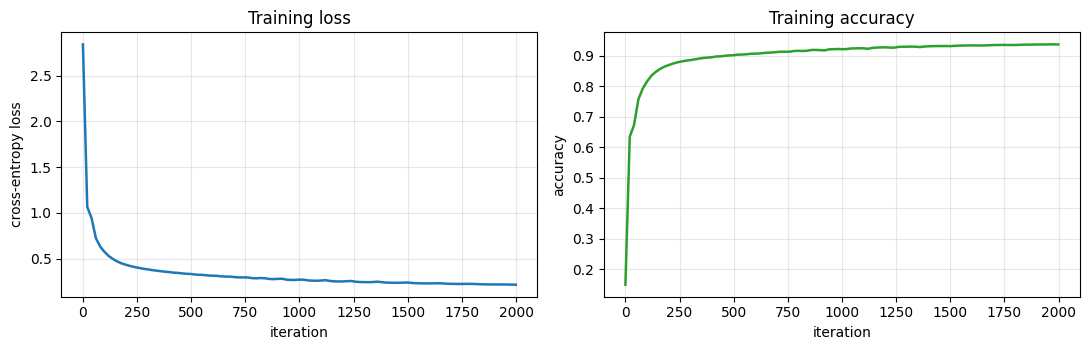

In [26]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 3.6))

ax_loss.plot(history["iteration"], history["loss"], lw=1.8)
ax_loss.set_xlabel("iteration")
ax_loss.set_ylabel("cross-entropy loss")
ax_loss.set_title("Training loss")
ax_loss.grid(alpha=0.3)

ax_acc.plot(history["iteration"], history["accuracy"], lw=1.8, color="tab:green")
ax_acc.set_xlabel("iteration")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Training accuracy")
ax_acc.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Evaluation

Training accuracy tells us how well the network memorized what it was shown.
We want to know how it does on the 8,400 unseen validation images. We evaluate by running forward propagation once with the trained
parameters — no backward pass, no update.

In [27]:
def predict(W1, b1, W2, b2, X):
    """Class predictions and full probability distributions for a batch."""
    _, _, _, A2 = forward_propagation(W1, b1, W2, b2, X)
    return get_predictions(A2), A2


train_predictions, _ = predict(W1, b1, W2, b2, X_train)
val_predictions, val_probabilities = predict(W1, b1, W2, b2, X_val)

print(f"training accuracy:   {get_accuracy(train_predictions, Y_train):.4f}")
print(f"validation accuracy: {get_accuracy(val_predictions, Y_val):.4f}")

training accuracy:   0.9370
validation accuracy: 0.9199


The two numbers are close, which means the network is **not overfitting**: with
only 7,960 parameters it does not have the capacity to memorize 33,600 images,
so what it learned generalizes. The gap between them is the quantity to watch
in any larger model — when training accuracy climbs while validation accuracy
stalls or falls, the model has begun memorizing rather than learning.

### 10.1 A single prediction

Let us look at one validation image together with the full distribution the
network assigns to it.

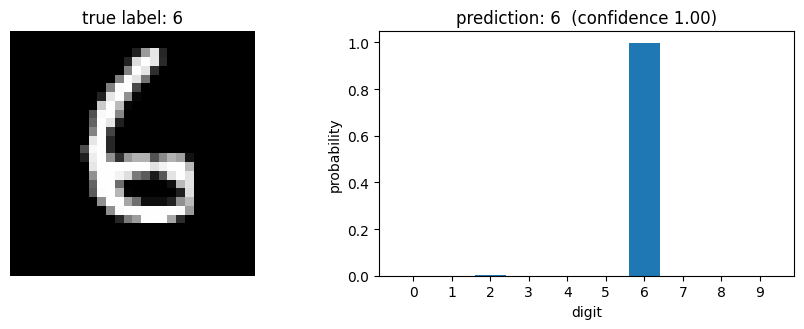

In [28]:
val_index = 500

image = X_val[:, val_index]
probabilities = val_probabilities[:, val_index]

fig, (ax_image, ax_bars) = plt.subplots(1, 2, figsize=(9, 3.4))

ax_image.imshow(image.reshape(28, 28), cmap="gray")
ax_image.set_title(f"true label: {Y_val[val_index]}")
ax_image.axis("off")

ax_bars.bar(np.arange(10), probabilities)
ax_bars.set_xticks(np.arange(10))
ax_bars.set_xlabel("digit")
ax_bars.set_ylabel("probability")
ax_bars.set_title(f"prediction: {np.argmax(probabilities)}  "
                  f"(confidence {probabilities.max():.2f})")

plt.tight_layout()
plt.show()

### 10.2 Where it goes wrong

The mistakes can be more informative than the successes.

673 errors out of 8400 validation images (8.0%)


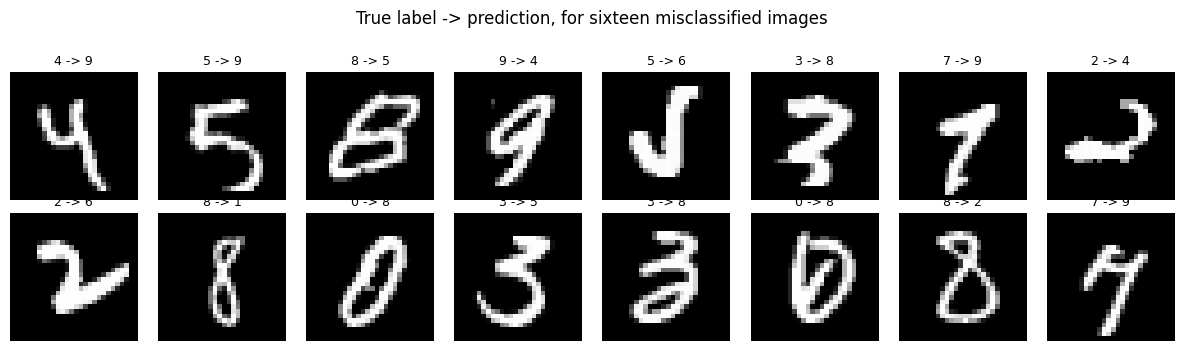

In [29]:
mistakes = np.flatnonzero(val_predictions != Y_val)
print(f"{mistakes.size} errors out of {Y_val.size} validation images "
      f"({100 * mistakes.size / Y_val.size:.1f}%)")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, idx in zip(axes.flat, mistakes[:16]):
    ax.imshow(X_val[:, idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"{Y_val[idx]} -> {val_predictions[idx]}", fontsize=9)
    ax.axis("off")
fig.suptitle("True label -> prediction, for sixteen misclassified images", y=1.02)
plt.tight_layout()
plt.show()

### 10.3 The confusion matrix

A confusion matrix $C$ collects the errors by kind: $C_{ij}$ is the number of
validation images whose true label is $i$ and whose predicted label is $j$.

$$
C_{ij} \;=\; \sum_{k=1}^{m} \mathbb{1}\!\left[y^{(k)} = i\right] \cdot \mathbb{1}\!\left[\hat{y}^{(k)} = j\right]
$$

A perfect classifier gives a purely diagonal matrix. The off-diagonal entries
name the specific confusions, i.e., which digits this network mistakes for which.

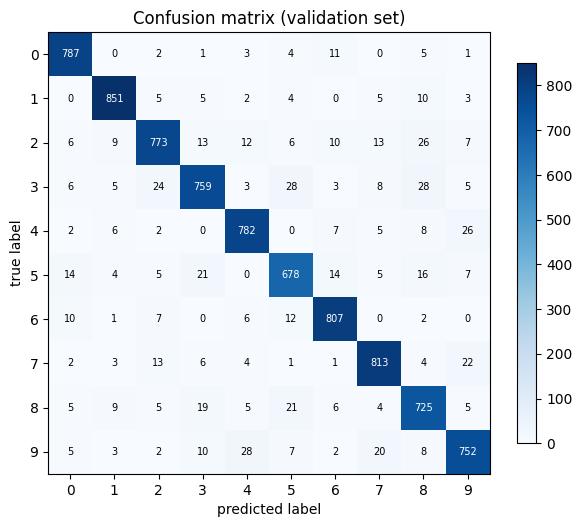

digit 0: 0.967
digit 1: 0.962
digit 2: 0.883
digit 3: 0.873
digit 4: 0.933
digit 5: 0.887
digit 6: 0.955
digit 7: 0.936
digit 8: 0.902
digit 9: 0.898


In [30]:
confusion = np.zeros((10, 10), dtype=int)
for true_label, predicted_label in zip(Y_val, val_predictions):
    confusion[true_label, predicted_label] += 1

fig, ax = plt.subplots(figsize=(6.2, 5.4))
image = ax.imshow(confusion, cmap="Blues")
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
ax.set_xlabel("predicted label")
ax.set_ylabel("true label")
ax.set_title("Confusion matrix (validation set)")

for i in range(10):
    for j in range(10):
        ax.text(j, i, confusion[i, j], ha="center", va="center", fontsize=7,
                color="white" if confusion[i, j] > confusion.max() / 2 else "black")

fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

per_class_accuracy = np.diag(confusion) / confusion.sum(axis=1)
for digit, accuracy in enumerate(per_class_accuracy):
    print(f"digit {digit}: {accuracy:.3f}")

---
## 11. What did the hidden layer learn?

Each row of $W^{[1]}$ is a vector of 784 weights — one per input pixel — so it
can be reshaped into a $28 \times 28$ image and looked at directly. That image
is the **template** the corresponding hidden unit responds to: since
$z^{[1]}_j = w_j^{\top} x + b_j$ is an inner product, the unit fires most
strongly on inputs that resemble its weight pattern. Red pixels push the unit's
activation up, blue pixels push it down.

The **top row** below shows the trained weights, and it looks mostly like
static. This is honest and worth understanding: the weights started as
$\mathcal{U}(-0.5, 0.5)$ noise, and a thousand gradient steps changed them by
much less than their initial spread. The learned signal is really there, but it
is buried under the random initialization it was added to.

The **bottom row** removes that noise floor by plotting the *change*,
$W^{[1]}_{\text{trained}} - W^{[1]}_{\text{initial}}$ — that is, everything
gradient descent actually contributed. Now the structure is unmistakable:
blobs and strokes concentrated in the centre of the frame, where digits are
drawn, and near-zero weight around the border, where MNIST images are always
blank. This bahavior was not specified. It evolved from minimizing the loss.

Two lessons hide in this pair of pictures. First, what a unit *does* depends on
its whole weight vector, but what it *learned* is the difference from where it
started.
Second, the near-zero border weights are the network discovering, on its own,
that those pixels carry no information.

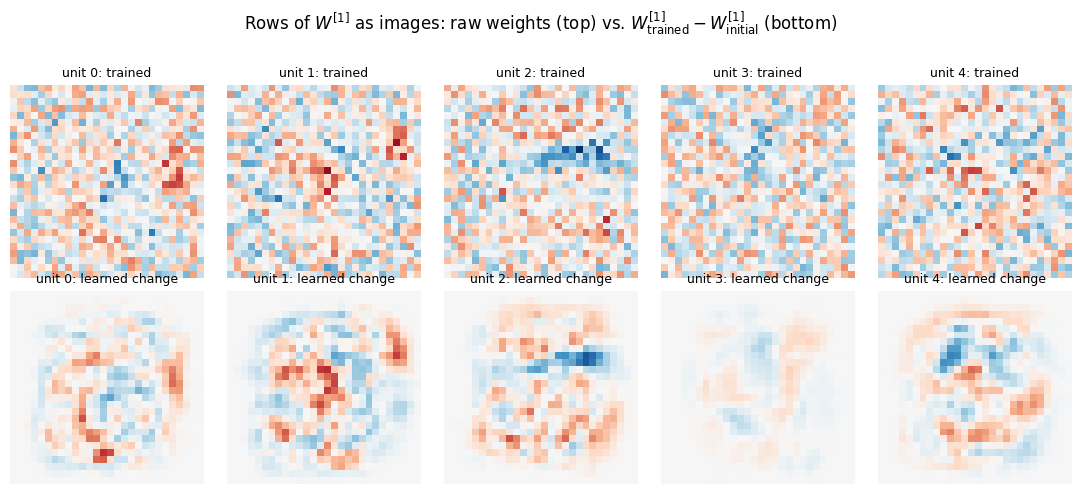

initial weight spread:        0.2895
std of the learned change:    0.1598


In [31]:
# Recover the initial weights: initialize_parameters is deterministic in RNG_SEED.
W1_initial, _, _, _ = initialize_parameters()
W1_learned = W1 - W1_initial

fig, axes = plt.subplots(2, 5, figsize=(11, 4.8))

trained_limit = np.abs(W1).max()
learned_limit = np.abs(W1_learned).max()

for unit in range(5):
    ax_top = axes[0, unit]
    ax_top.imshow(W1[unit].reshape(28, 28), cmap="RdBu_r",
                  vmin=-trained_limit, vmax=trained_limit)
    ax_top.set_title(f"unit {unit}: trained", fontsize=9)
    ax_top.axis("off")

    ax_bottom = axes[1, unit]
    ax_bottom.imshow(W1_learned[unit].reshape(28, 28), cmap="RdBu_r",
                     vmin=-learned_limit, vmax=learned_limit)
    ax_bottom.set_title(f"unit {unit}: learned change", fontsize=9)
    ax_bottom.axis("off")

fig.suptitle(r"Rows of $W^{[1]}$ as images: raw weights (top) vs. "
             r"$W^{[1]}_{\rm trained} - W^{[1]}_{\rm initial}$ (bottom)", y=1.02)
plt.tight_layout()
plt.show()

print(f"initial weight spread:        {W1_initial.std():.4f}")
print(f"std of the learned change:    {W1_learned.std():.4f}")

---
## 12. Appendix: checking the gradients numerically

Backpropagation is where hand-written networks go wrong, and the failure is
insidious: a transposed matrix or a sum over the wrong axis often still trains,
just worse, with nothing to indicate that anything is broken. **Gradient
checking** is the standard defence.

The idea is to compare the analytic gradient against a finite-difference
approximation. For a single scalar parameter $\theta$, the centred difference

$$
\frac{\partial \mathcal{L}}{\partial \theta}
\;\approx\;
\frac{\mathcal{L}(\theta + \varepsilon) - \mathcal{L}(\theta - \varepsilon)}{2\varepsilon}
$$

has error $O(\varepsilon^2)$, which is far better than the one-sided version's
$O(\varepsilon)$. We then compare the two vectors with a relative error:

$$
\text{relative error}
\;=\;
\frac{\left\lVert g_{\text{numerical}} - g_{\text{analytic}} \right\rVert_2}
     {\left\lVert g_{\text{numerical}} \right\rVert_2 + \left\lVert g_{\text{analytic}} \right\rVert_2}
$$

The rule of thumb: below $10^{-7}$ the gradients agree; above $10^{-4}$
something is wrong.

Two practical points. The check is far too slow to run during training — it
costs two full forward passes *per parameter* — so we sample a handful of
coordinates on a handful of examples. And $\varepsilon$ cannot be made
arbitrarily small: below about $10^{-7}$ the subtraction of two nearly equal
floating-point numbers loses more precision than the approximation gains.
$\varepsilon = 10^{-6}$ is a good compromise.

> ReLU's kink at $z = 0$ can make an individual coordinate fail this check, since
> the finite difference straddles a point where the derivative jumps. With a
> small sample of coordinates this is rare, but it is the one reason
> for a large relative error here.

In [32]:
def gradient_check(n_examples=5, n_samples=20, epsilon=1e-6, seed=1):
    """Compare analytic gradients against centred finite differences."""
    check_rng = np.random.default_rng(seed)
    X_small = X_train[:, :n_examples]
    Y_small = one_hot(Y_train[:n_examples])

    parameters = list(initialize_parameters(seed=3))
    Z1, A1, Z2, A2 = forward_propagation(*parameters, X_small)
    gradients = backward_propagation(parameters[2], Z1, A1, A2, X_small, Y_small)

    def loss_now():
        return cross_entropy_loss(forward_propagation(*parameters, X_small)[3], Y_small)

    print(f"{'parameter':<10} {'relative error':>16}   verdict")
    for name, P, dP in zip(["W1", "b1", "W2", "b2"], parameters, gradients):
        numerical, analytic = [], []
        for _ in range(n_samples):
            index = tuple(check_rng.integers(0, size) for size in P.shape)
            original = P[index]

            P[index] = original + epsilon
            loss_plus = loss_now()
            P[index] = original - epsilon
            loss_minus = loss_now()
            P[index] = original                       # restore

            numerical.append((loss_plus - loss_minus) / (2 * epsilon))
            analytic.append(dP[index])

        numerical, analytic = np.array(numerical), np.array(analytic)
        relative_error = (np.linalg.norm(numerical - analytic) /
                          (np.linalg.norm(numerical) + np.linalg.norm(analytic) + 1e-12))
        verdict = "PASS" if relative_error < 1e-7 else "CHECK THIS"
        print(f"{name:<10} {relative_error:16.3e}   {verdict}")


gradient_check()

parameter    relative error   verdict
W1                6.513e-08   PASS
b1                8.901e-08   PASS
W2                4.077e-08   PASS
b2                5.904e-08   PASS


---
## 13. Summary

### What we built

The whole network, in six equations forward and six back:

| | Forward | Backward |
|---|---|---|
| output | $A^{[2]} = \operatorname{softmax}(Z^{[2]})$ | $dZ^{[2]} = A^{[2]} - Y$ |
| | $Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}$ | $dW^{[2]} = \tfrac{1}{m}dZ^{[2]}A^{[1]\top}$, $\;db^{[2]} = \tfrac{1}{m}dZ^{[2]}\mathbf{1}$ |
| hidden | $A^{[1]} = \operatorname{ReLU}(Z^{[1]})$ | $dZ^{[1]} = W^{[2]\top}dZ^{[2]} \odot \mathbb{1}[Z^{[1]}>0]$ |
| | $Z^{[1]} = W^{[1]}X + b^{[1]}$ | $dW^{[1]} = \tfrac{1}{m}dZ^{[1]}X^{\top}$, $\;db^{[1]} = \tfrac{1}{m}dZ^{[1]}\mathbf{1}$ |

Then $\theta \leftarrow \theta - \alpha \, d\theta$, repeated a thousand times.

Everything a deep learning framework does is a generalization of this: more
layers, better optimizers, convolutions instead of dense layers, and an
autograd engine that derives the backward column from the forward one. The
arithmetic in the right-hand column is what `loss.backward()` performs.
